# Complete Guide to the Lexos Corpus Module

This comprehensive tutorial will guide you through the corpus module, showing you how to manage document collections, perform statistical analysis, and integrate with other Lexos modules. Whether you're analyzing literary texts, research papers, or any other document collection, this notebook provides a template workflow you can easily adapt to your needs.

> **⚠️ Important Setup Note:** Before running this notebook, make sure you have the spaCy language model installed:
> ```bash
> python -m spacy download en_core_web_sm
> ```

## Table of Contents
1. [Setup and Prerequisites](#setup)
2. [Creating and Managing a Corpus](#creating)
3. [Adding Documents (Your Data Goes Here)](#adding)
4. [Document Processing and Metadata](#processing)
5. [Statistical Analysis and Performance](#analysis)
6. [Finding Patterns and Outliers](#patterns)
7. [Visualization and Reporting](#visualization)
8. [Inter-Module Integration](#integration)
9. [Saving and Sharing Your Work](#saving)
10. [Template for Your Research](#template)

---

<a id="setup"></a>
## 1. Setup and Prerequisites

First, let's import everything you'll need and set up the environment:

In [1]:
# Core imports
import warnings
import tempfile
import time
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import spacy

# Lexos corpus module
from lexos.corpus import Corpus, Record
from lexos.corpus.corpus_stats import CorpusStats

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore", message=".*Expected `str` but got `UUID`.*")
warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

# Load spaCy model
try:
    nlp = spacy.load("en_core_web_sm")
    print("✓ spaCy model loaded successfully!")
except OSError:
    print("❌ spaCy model not found. Please run: python -m spacy download en_core_web_sm")
    print("   Then restart this notebook.")

print("✓ Setup complete! Ready to work with corpora.")
print(f"✓ Working directory: {Path.cwd()}")

✓ spaCy model loaded successfully!
✓ Setup complete! Ready to work with corpora.
✓ Working directory: c:\Users\aaron\uv_lexos\src\lexos\corpus


<a id="creating"></a>
## 2. Creating and Managing a Corpus

A corpus is a collection of documents that you want to analyze together. Let's create one:

In [2]:
# CHANGE THIS: Replace with your project name and directory
corpus_name = "My Research Corpus"  # Your project name
corpus_directory = tempfile.mkdtemp()  # Or use a permanent directory like "./my_corpus"

# Create the corpus
corpus = Corpus(
    name=corpus_name,
    corpus_dir=corpus_directory
)

print(f"📚 Created corpus: {corpus.name}")
print(f"📁 Storage location: {corpus.corpus_dir}")
print(f"📊 Current state:")
print(f"   - Documents: {corpus.num_docs}")
print(f"   - Active documents: {corpus.num_active_docs}")
print(f"   - Total tokens: {corpus.num_tokens}")

Corpus created.
📚 Created corpus: My Research Corpus
📁 Storage location: C:\Users\aaron\AppData\Local\Temp\tmpgrcuxt1f
📊 Current state:
   - Documents: 0
   - Active documents: 0
   - Total tokens: 0


<a id="adding"></a>
## 3. Adding Documents (Your Data Goes Here)

Now let's add your documents to the corpus. You can add documents from files, direct text, or any other source.

### Option A: Add From Files (Recommended)

In [3]:
# CHANGE THIS: Add your files here
# Replace these example file paths with your actual files
file_paths = [
    # "path/to/your/document1.txt",
    # "path/to/your/document2.txt",
    # "path/to/your/document3.txt",
]

# If you don't have files ready, we'll use sample texts for demonstration
if not file_paths:
    print("📝 Using sample texts for demonstration...")
    
    # REPLACE THESE with your actual texts
    sample_texts = {
        "sample_literature": "In a hole in the ground there lived a hobbit. Not a nasty, dirty, wet hole, filled with the ends of worms and an oozy smell, nor yet a dry, bare, sandy hole with nothing in it to sit down on or to eat: it was a hobbit-hole, and that means comfort.",
        
        "sample_academic": "The rapid advancement of artificial intelligence has profound implications for various sectors of society. Machine learning algorithms are increasingly being deployed in healthcare, finance, and education, raising important questions about accountability, transparency, and fairness in automated decision-making systems.",
        
        "sample_news": "Local authorities announced today that the new community center will open next month. The facility will feature a library, gymnasium, and meeting spaces for local organizations. Residents have been eagerly anticipating the opening since construction began two years ago.",
        
        "sample_dialogue": "\"How are you today?\" she asked with a smile. \"I'm doing well, thank you,\" he replied. \"The weather is beautiful, isn't it?\" \"Yes, perfect for a walk in the park,\" she agreed enthusiastically.",
        
        "sample_technical": "The implementation requires instantiation of the primary data structure followed by iterative processing of the input parameters. Error handling mechanisms must be incorporated to ensure robust operation under various edge case conditions and unexpected input variations."
    }
    
    # Add sample texts to corpus
    for doc_name, text_content in sample_texts.items():
        corpus.add(
            content=text_content,
            name=doc_name,
            is_active=True,
            metadata={'type': 'sample', 'category': doc_name.split('_')[1]}
        )
    
    print(f"✓ Added {len(sample_texts)} sample documents")

else:
    # Load your actual files
    for file_path in file_paths:
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                content = f.read()
            
            doc_name = Path(file_path).stem  # Use filename without extension
            corpus.add(
                content=content,
                name=doc_name,
                is_active=True,
                metadata={'source_file': file_path}
            )
            print(f"✓ Added: {doc_name}")
            
        except FileNotFoundError:
            print(f"❌ File not found: {file_path}")
        except Exception as e:
            print(f"❌ Error loading {file_path}: {e}")

print(f"\n📊 Corpus Status:")
print(f"   - Total documents: {corpus.num_docs}")
print(f"   - Active documents: {corpus.num_active_docs}")

📝 Using sample texts for demonstration...
✓ Added 5 sample documents

📊 Corpus Status:
   - Total documents: 5
   - Active documents: 5


### Option B: Add Processed spaCy Documents (For Advanced Analysis)

In [4]:
# CHANGE THIS: Decide if you want linguistic processing
enable_linguistic_processing = True  # Set to False if you only need basic text analysis

if enable_linguistic_processing:
    print("🔬 Adding linguistically processed documents...")
    
    # Process each document with spaCy for advanced linguistic analysis
    processed_count = 0
    for record_id, record in list(corpus.records.items()):
        if not record.is_parsed:  # Only process if not already processed
            try:
                # Process with spaCy
                processed_doc = nlp(record.content)
                
                # Add processed version
                corpus.add(
                    content=processed_doc,
                    name=f"{record.name}_processed",
                    model="en_core_web_sm",
                    is_active=True,
                    metadata={
                        **record.meta,  # Copy original metadata
                        'processing': 'spacy_nlp',
                        'original_doc': record.name
                    }
                )
                processed_count += 1
                
            except Exception as e:
                print(f"⚠️ Failed to process {record.name}: {e}")
    
    print(f"✓ Processed {processed_count} documents with spaCy")
    print(f"💡 Processed documents enable advanced features like:")
    print(f"   - Part-of-speech analysis")
    print(f"   - Named entity recognition")
    print(f"   - Dependency parsing")
    print(f"   - Advanced statistical metrics")

else:
    print("📝 Skipping linguistic processing (working with plain text only)")

print(f"\n📊 Final Corpus Status:")
print(f"   - Total documents: {corpus.num_docs}")
print(f"   - Active documents: {corpus.num_active_docs}")

🔬 Adding linguistically processed documents...
✓ Processed 5 documents with spaCy
💡 Processed documents enable advanced features like:
   - Part-of-speech analysis
   - Named entity recognition
   - Dependency parsing
   - Advanced statistical metrics

📊 Final Corpus Status:
   - Total documents: 10
   - Active documents: 10


<a id="processing"></a>
## 4. Document Processing and Metadata

Let's explore the documents in your corpus and see how to work with metadata:

In [5]:
# Explore your corpus structure
print("📋 CORPUS OVERVIEW")
print("=" * 40)

# Show document details
for i, (record_id, record) in enumerate(corpus.records.items()):
    print(f"\n📄 Document {i+1}: {record.name}")
    print(f"   ID: {record_id}")
    print(f"   Active: {record.is_active}")
    print(f"   Processed: {record.is_parsed}")
    print(f"   Content type: {'spaCy Doc' if record.is_parsed else 'Plain text'}")
    
    if record.is_parsed:
        print(f"   Model: {record.model}")
        print(f"   Tokens: {record.num_tokens()}")
        print(f"   Unique terms: {record.num_terms()}")
    
    # Show metadata
    if record.meta:
        print(f"   Metadata: {record.meta}")
    
    # Show preview
    preview = record.preview
    print(f"   Preview: {preview[:100]}..." if len(preview) > 100 else f"   Preview: {preview}")

print(f"\n\n🎯 QUICK ACCESS EXAMPLES")
print("=" * 40)

# Show how to access documents
if corpus.num_docs > 0:
    # Get first document by name
    first_doc_name = list(corpus.names.keys())[0]
    first_doc = corpus.get(name=first_doc_name)
    print(f"✓ Retrieved document by name: {first_doc.name}")
    
    # Get document by ID
    first_id = list(corpus.records.keys())[0]
    same_doc = corpus.get(id=first_id)
    print(f"✓ Retrieved same document by ID: {same_doc.name}")
    
    # Show document content access
    if first_doc.is_parsed:
        print(f"✓ spaCy features available:")
        print(f"   - First 5 tokens: {[token.text for token in first_doc.content[:5]]}")
        print(f"   - POS tags: {[token.pos_ for token in first_doc.content[:5]]}")
    else:
        print(f"✓ Plain text access: {len(first_doc.content)} characters")

📋 CORPUS OVERVIEW

📄 Document 1: sample_literature
   ID: 300abbfc-acd0-4ea7-a17f-c6a4a112d660
   Active: True
   Processed: False
   Content type: Plain text
   Metadata: {'type': 'sample', 'category': 'literature', 'filename': '300abbfc-acd0-4ea7-a17f-c6a4a112d660.bin', 'filepath': 'C:\\Users\\aaron\\AppData\\Local\\Temp\\tmpgrcuxt1f\\data\\300abbfc-acd0-4ea7-a17f-c6a4a112d660.bin'}
   Preview: In a hole in the ground there lived a hobbit. Not a nasty, dirty, wet hole, filled with the ends of ...

📄 Document 2: sample_academic
   ID: cfb97446-efdc-4ce7-a187-3bb9be6636a3
   Active: True
   Processed: False
   Content type: Plain text
   Metadata: {'type': 'sample', 'category': 'academic', 'filename': 'cfb97446-efdc-4ce7-a187-3bb9be6636a3.bin', 'filepath': 'C:\\Users\\aaron\\AppData\\Local\\Temp\\tmpgrcuxt1f\\data\\cfb97446-efdc-4ce7-a187-3bb9be6636a3.bin'}
   Preview: The rapid advancement of artificial intelligence has profound implications for various sectors of so...

📄 Document 3:

### Adding Custom Metadata

You can add any metadata you need to documents:

In [6]:
# CHANGE THIS: Add metadata relevant to your research
# This is where you can tag documents with categories, dates, authors, etc.

print("🏷️ ADDING CUSTOM METADATA")
print("=" * 40)

# Example metadata you might want to add:
for record_id, record in corpus.records.items():
    # Add custom metadata based on your research needs
    current_meta = record.meta.copy() if record.meta else {}
    
    # CHANGE THESE examples to your actual categories:
    if 'literature' in record.name:
        current_meta.update({
            'genre': 'fiction',
            'period': 'modern',
            'analysis_priority': 'high'
        })
    elif 'academic' in record.name:
        current_meta.update({
            'genre': 'academic',
            'field': 'computer_science',
            'analysis_priority': 'high'
        })
    elif 'news' in record.name:
        current_meta.update({
            'genre': 'journalism',
            'topic': 'local_news',
            'analysis_priority': 'medium'
        })
    else:
        current_meta.update({
            'genre': 'other',
            'analysis_priority': 'low'
        })
    
    # Add timestamp
    current_meta['added_to_corpus'] = time.strftime('%Y-%m-%d %H:%M:%S')
    
    # Update the record's metadata
    record.meta = current_meta
    
    print(f"✓ Updated metadata for {record.name}")

print("\n📊 Metadata Summary:")
# Show metadata statistics
all_genres = [record.meta.get('genre', 'unknown') for record in corpus.records.values()]
genre_counts = pd.Series(all_genres).value_counts()
print(genre_counts)

print("\n💡 TIP: You can filter documents by metadata:")
high_priority_docs = [r for r in corpus.records.values() 
                      if r.meta.get('analysis_priority') == 'high']
print(f"   - High priority documents: {len(high_priority_docs)}")

🏷️ ADDING CUSTOM METADATA
✓ Updated metadata for sample_literature
✓ Updated metadata for sample_academic
✓ Updated metadata for sample_news
✓ Updated metadata for sample_dialogue
✓ Updated metadata for sample_technical
✓ Updated metadata for sample_literature_processed
✓ Updated metadata for sample_academic_processed
✓ Updated metadata for sample_news_processed
✓ Updated metadata for sample_dialogue_processed
✓ Updated metadata for sample_technical_processed

📊 Metadata Summary:
other         4
fiction       2
academic      2
journalism    2
Name: count, dtype: int64

💡 TIP: You can filter documents by metadata:
   - High priority documents: 4


<a id="analysis"></a>
## 5. Statistical Analysis

Now let's analyze your corpus with the statistical engine:

In [7]:
# Generate comprehensive corpus statistics
print("📊 GENERATING CORPUS STATISTICS")
print("=" * 40)

# Get statistics (this may take a moment for large corpora)
stats = corpus.get_stats(active_only=True)

print(f"✓ Statistics generated for {len(stats.docs)} documents")
print(f"✓ Using DTM with {len(stats.dtm.sorted_terms_list)} unique terms")

# Basic statistics
print(f"\n📈 BASIC STATISTICS")
print(f"   Mean document length: {stats.mean:.1f} tokens")
print(f"   Standard deviation: {stats.standard_deviation:.1f} tokens")
print(f"   Shortest document: {stats.doc_stats_df['total_tokens'].min()} tokens")
print(f"   Longest document: {stats.doc_stats_df['total_tokens'].max()} tokens")

# Document-level statistics table
print(f"\n📋 DOCUMENT-LEVEL STATISTICS")
doc_stats_display = stats.doc_stats_df.copy()
doc_stats_display.index.name = 'Document'
print(doc_stats_display)

📊 GENERATING CORPUS STATISTICS
✓ Statistics generated for 10 documents
✓ Using DTM with 197 unique terms

📈 BASIC STATISTICS
   Mean document length: 44.4 tokens
   Standard deviation: 9.6 tokens
   Shortest document: 33 tokens
   Longest document: 64 tokens

📋 DOCUMENT-LEVEL STATISTICS
                             hapax_legomena  total_tokens  total_terms  \
Document                                                                 
sample_literature                        33            52           41   
sample_academic                          32            38           35   
sample_news                              35            39           37   
sample_dialogue                          29            33           31   
sample_technical                         30            36           33   
sample_literature_processed              32            64           43   
sample_academic_processed                34            47           39   
sample_news_processed                    35   

### IQR Analysis and Outlier Detection

Let's explore the statistical measures available:

In [8]:
print("🎯 IQR ANALYSIS AND OUTLIER DETECTION")
print("=" * 40)

# Get IQR analysis results
iqr_values = stats.iqr_values
iqr_bounds = stats.iqr_bounds
outliers = stats.iqr_outliers

print(f"📊 IQR Analysis Results:")
print(f"   Q1 (25th percentile): {iqr_values[0]:.2f}")
print(f"   Q3 (75th percentile): {iqr_values[1]:.2f}")
print(f"   IQR (Q3 - Q1): {iqr_values[2]:.2f}")
print(f"   Lower bound: {iqr_bounds[0]:.2f}")
print(f"   Upper bound: {iqr_bounds[1]:.2f}")

print(f"\n🔍 Outlier Detection:")
if outliers:
    print(f"   Found {len(outliers)} outlier(s):")
    for doc_id, doc_name in outliers:
        doc_record = corpus.get(id=doc_id)
        if doc_record.is_parsed:
            token_count = doc_record.num_tokens()
            print(f"   📄 {doc_name}: {token_count} tokens")
        else:
            char_count = len(doc_record.content)
            print(f"   📄 {doc_name}: {char_count} characters")
else:
    print("   ✓ No outliers detected - documents are similar in length")

print(f"\n💡 Statistical Insights:")
print(f"   ✓ IQR provides robust measure of document length variability")
print(f"   ✓ Outliers may indicate unique documents worth investigating")
print(f"   ✓ Consistent document lengths suggest well-curated corpus")

🎯 IQR ANALYSIS AND OUTLIER DETECTION
📊 IQR Analysis Results:
   Q1 (25th percentile): 38.00
   Q3 (75th percentile): 50.75
   IQR (Q3 - Q1): 12.75
   Lower bound: 18.88
   Upper bound: 69.88

🔍 Outlier Detection:
   ✓ No outliers detected - documents are similar in length

💡 Statistical Insights:
   ✓ IQR provides robust measure of document length variability
   ✓ Outliers may indicate unique documents worth investigating
   ✓ Consistent document lengths suggest well-curated corpus


### Advanced Statistical Metrics

Explore the advanced statistical capabilities:

In [9]:
print("📈 ADVANCED STATISTICAL ANALYSIS")
print("=" * 40)

# Distribution statistics
dist_stats = stats.distribution_stats
print(f"📊 Distribution Statistics:")
print(f"   Skewness: {dist_stats['skewness']:.3f}")
print(f"   Kurtosis: {dist_stats['kurtosis']:.3f}")
print(f"   Coefficient of variation: {dist_stats['coefficient_of_variation']:.3f}")
print(f"   Normal distribution: {dist_stats['is_normal']}")
print(f"   Shapiro-Wilk p-value: {dist_stats['shapiro_p_value']:.6f}")

# Text diversity statistics
diversity_stats = stats.text_diversity_stats
print(f"\n📚 Text Diversity Statistics:")
print(f"   Mean TTR: {diversity_stats['mean_ttr']:.3f}")
print(f"   Corpus TTR: {diversity_stats['corpus_ttr']:.3f}")
print(f"   Mean hapax ratio: {diversity_stats['mean_hapax_ratio']:.3f}")
print(f"   Total hapax legomena: {diversity_stats['total_hapax']}")

# Corpus quality metrics
quality_metrics = stats.corpus_quality_metrics
print(f"\n🎯 Corpus Quality Assessment:")
length_balance = quality_metrics['document_length_balance']
print(f"   Document length balance: {length_balance['classification']}")
print(f"   Length CV: {length_balance['coefficient_variation']:.3f}")

vocab_balance = quality_metrics['vocabulary_density_balance']
print(f"   Vocabulary density balance: {vocab_balance['classification']}")

sampling = quality_metrics['vocabulary_richness']
print(f"   Sampling adequacy: {sampling['sampling_adequacy']}")
print(f"   Vocabulary saturation: {sampling['vocabulary_saturation']:.3f}")

size_metrics = quality_metrics['corpus_size_metrics']
print(f"   Size adequacy: {size_metrics['size_adequacy']}")
print(f"   Recommended min docs: {size_metrics['recommended_min_docs']}")

# Percentile analysis
percentiles = stats.percentiles
print(f"\n📊 Percentile Analysis:")
print(f"   5th percentile: {percentiles['percentile_5']:.1f}")
print(f"   25th percentile (Q1): {percentiles['percentile_25']:.1f}")
print(f"   50th percentile (Median): {percentiles['percentile_50']:.1f}")
print(f"   75th percentile (Q3): {percentiles['percentile_75']:.1f}")
print(f"   95th percentile: {percentiles['percentile_95']:.1f}")
print(f"   Range: {percentiles['range']:.1f}")

📈 ADVANCED STATISTICAL ANALYSIS
📊 Distribution Statistics:
   Skewness: 0.770
   Kurtosis: -0.379
   Coefficient of variation: 0.217
   Normal distribution: True
   Shapiro-Wilk p-value: 0.344736

📚 Text Diversity Statistics:
   Mean TTR: 0.846
   Corpus TTR: 0.444
   Mean hapax ratio: 0.740
   Total hapax legomena: 317

🎯 Corpus Quality Assessment:
   Document length balance: balanced
   Length CV: 0.206
   Vocabulary density balance: very_balanced
   Sampling adequacy: insufficient
   Vocabulary saturation: 1.609
   Size adequacy: small
   Recommended min docs: 30

📊 Percentile Analysis:
   5th percentile: 34.4
   25th percentile (Q1): 38.0
   50th percentile (Median): 41.5
   75th percentile (Q3): 50.8
   95th percentile: 59.0
   Range: 31.0


<a id="patterns"></a>
## 6. Finding Patterns and Outliers

Let's identify interesting patterns and outliers in your corpus:

In [10]:
print("🔍 OUTLIER DETECTION")
print("=" * 40)

# IQR-based outliers
iqr_outliers = stats.get_iqr_outliers()
print(f"📊 IQR Outliers ({len(iqr_outliers)} found):")
if iqr_outliers:
    for doc_id, doc_name in iqr_outliers:
        doc_record = corpus.get(id=doc_id)
        if doc_record.is_parsed:
            token_count = doc_record.num_tokens()
            print(f"   📄 {doc_name}: {token_count} tokens")
        else:
            char_count = len(doc_record.content)
            print(f"   📄 {doc_name}: {char_count} characters")
else:
    print("   ✓ No outliers detected - documents are similar in length")

# Standard deviation outliers
std_outliers = stats.get_std_outliers()
print(f"\n📈 Standard Deviation Outliers ({len(std_outliers)} found):")
if std_outliers:
    for doc_id, doc_name in std_outliers:
        print(f"   📄 {doc_name}")
else:
    print("   ✓ No extreme outliers detected")

print(f"\n🧠 PATTERN ANALYSIS")
print("=" * 40)

# Analyze patterns by metadata
if any(record.meta.get('genre') for record in corpus.records.values()):
    print(f"📚 Analysis by Genre:")
    
    # Group documents by genre
    genre_stats = {}
    for record in corpus.records.values():
        if record.is_active:
            genre = record.meta.get('genre', 'unknown')
            if genre not in genre_stats:
                genre_stats[genre] = {'docs': [], 'lengths': []}
            
            genre_stats[genre]['docs'].append(record.name)
            if record.is_parsed:
                genre_stats[genre]['lengths'].append(record.num_tokens())
            else:
                genre_stats[genre]['lengths'].append(len(record.content))
    
    # Show genre statistics
    for genre, data in genre_stats.items():
        avg_length = sum(data['lengths']) / len(data['lengths'])
        print(f"   {genre}: {len(data['docs'])} docs, avg length: {avg_length:.1f}")

# Show top terms
print(f"\n🔤 Most Frequent Terms:")
try:
    top_terms = corpus.term_counts(n=10, most_common=True)
    for i, (term, count) in enumerate(top_terms, 1):
        print(f"   {i:2d}. {term}: {count}")
except:
    print("   (Term counting requires processed documents)")

🔍 OUTLIER DETECTION
📊 IQR Outliers (0 found):
   ✓ No outliers detected - documents are similar in length

📈 Standard Deviation Outliers (1 found):
   📄 sample_literature_processed

🧠 PATTERN ANALYSIS
📚 Analysis by Genre:
   fiction: 2 docs, avg length: 155.5
   academic: 2 docs, avg length: 183.5
   journalism: 2 docs, avg length: 157.0
   other: 4 docs, avg length: 138.2

🔤 Most Frequent Terms:
    1. ,: 19
    2. .: 12
    3. a: 8
    4. ": 8
    5. the: 7
    6. and: 6
    7. in: 5
    8. of: 5
    9. hole: 4
   10. The: 4


### Advanced Pattern Analysis

In [11]:
print("🔬 ADVANCED PATTERN ANALYSIS")
print("=" * 40)

# Zipf's Law Analysis
zipf_analysis = stats.zipf_analysis
print(f"📈 Zipf's Law Analysis:")
print(f"   Zipf slope: {zipf_analysis['zipf_slope']:.3f}")
print(f"   R-squared: {zipf_analysis['r_squared']:.3f}")
print(f"   Goodness of fit: {zipf_analysis['zipf_goodness_of_fit']}")
print(f"   Follows Zipf's law: {zipf_analysis['follows_zipf']}")
print(f"   Terms analyzed: {zipf_analysis['num_terms']}")

if zipf_analysis['follows_zipf']:
    print(f"   ✓ Your corpus follows expected frequency patterns")
else:
    print(f"   ⚠️ Unusual frequency distribution detected")

# Lexical diversity analysis
diversity_analysis = stats.advanced_lexical_diversity
print(f"\n📚 Advanced Lexical Diversity:")
print(f"   Mean CTTR: {diversity_analysis['mean_cttr']:.3f}")
print(f"   Mean RTTR: {diversity_analysis['mean_rttr']:.3f}")
print(f"   Mean Log TTR: {diversity_analysis['mean_log_ttr']:.3f}")
print(f"   Diversity range: {diversity_analysis['diversity_range']:.3f}")
print(f"   Diversity CV: {diversity_analysis['diversity_coefficient_variation']:.3f}")

# Compare groups if we have metadata categories
if len(genre_stats) > 1:
    print(f"\n🔬 Statistical Group Comparison:")
    
    # Get two groups for comparison
    genres = list(genre_stats.keys())
    if len(genres) >= 2:
        group1_docs = [doc for doc in genre_stats[genres[0]]['docs']]
        group2_docs = [doc for doc in genre_stats[genres[1]]['docs']]
        
        try:
            comparison = stats.compare_groups(
                group1_labels=group1_docs,
                group2_labels=group2_docs,
                metric="total_tokens",
                test_type="mann_whitney"
            )
            
            print(f"   Comparing {genres[0]} vs {genres[1]}:")
            print(f"   Group 1 mean: {comparison['group1_mean']:.1f}")
            print(f"   Group 2 mean: {comparison['group2_mean']:.1f}")
            print(f"   P-value: {comparison['p_value']:.4f}")
            print(f"   Significant difference: {comparison['is_significant']}")
            print(f"   Effect size: {comparison['effect_size_interpretation']}")
            
        except Exception as e:
            print(f"   Could not compare groups: {e}")

🔬 ADVANCED PATTERN ANALYSIS
📈 Zipf's Law Analysis:
   Zipf slope: -0.044
   R-squared: 0.005
   Goodness of fit: poor
   Follows Zipf's law: False
   Terms analyzed: 197
   ⚠️ Unusual frequency distribution detected

📚 Advanced Lexical Diversity:
   Mean CTTR: 3.921
   Mean RTTR: 5.545
   Mean Log TTR: 0.955
   Diversity range: 0.288
   Diversity CV: 0.126

🔬 Statistical Group Comparison:
   Comparing fiction vs academic:
   Group 1 mean: 58.0
   Group 2 mean: 42.5
   P-value: 0.3333
   Significant difference: False
   Effect size: large


<a id="visualization"></a>
## 7. Visualization and Reporting

Create visualizations of your corpus statistics:

📊 CREATING VISUALIZATIONS


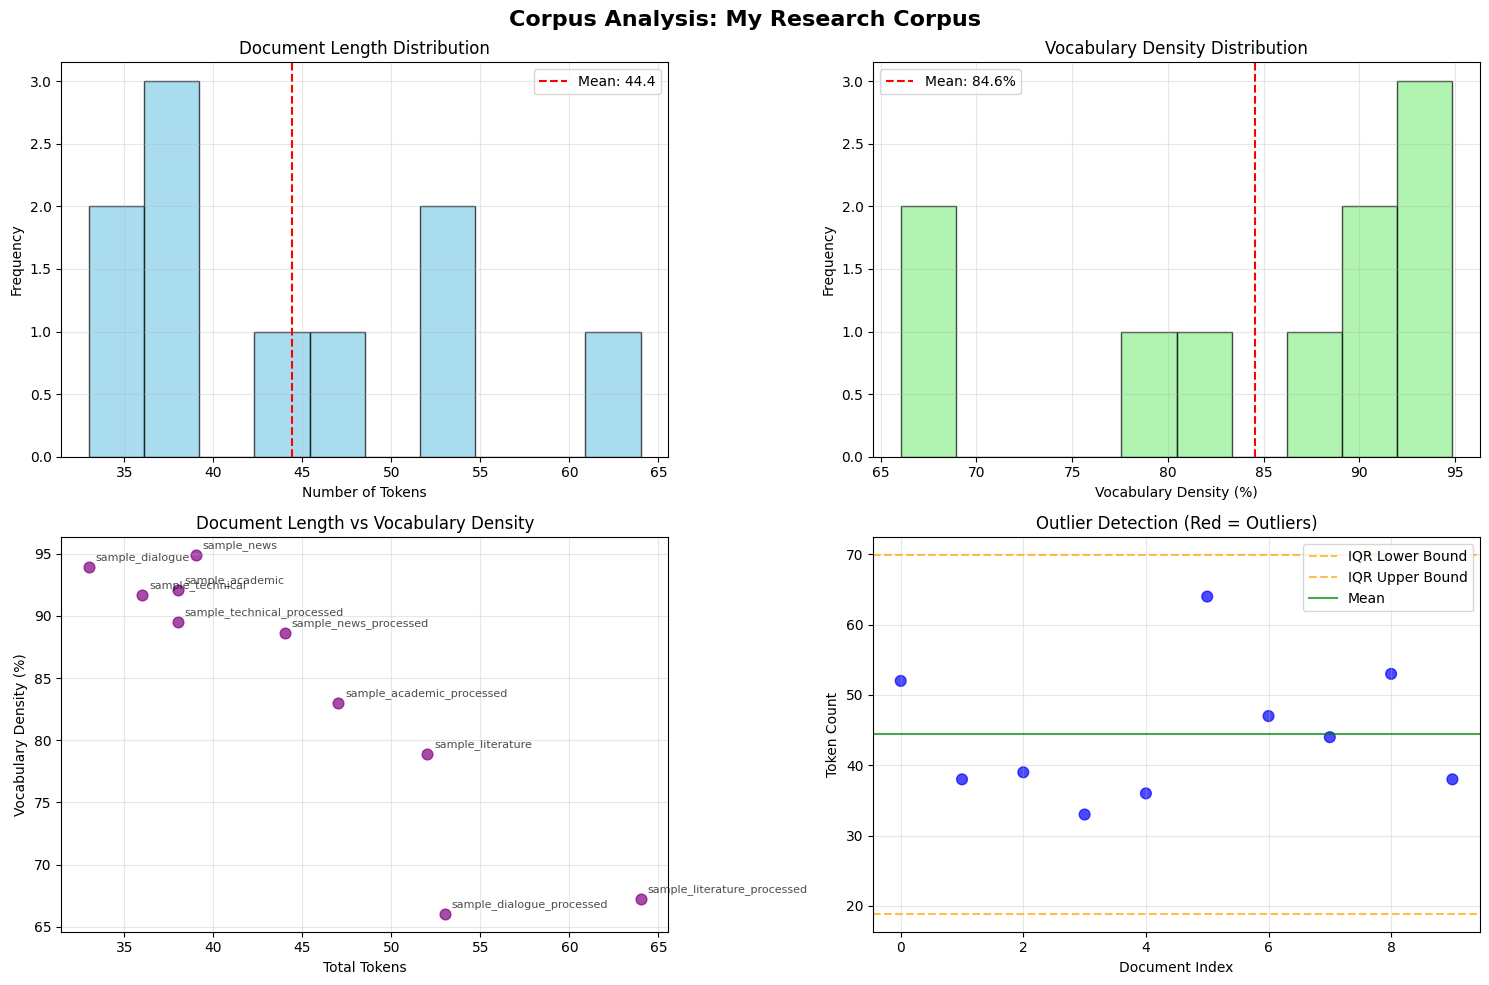

✓ Visualization complete!

💡 Interpretation Guide:
   📊 Top Left: Shows how document lengths are distributed
   📈 Top Right: Shows vocabulary richness patterns
   🔍 Bottom Left: Reveals relationships between length and vocabulary
   🎯 Bottom Right: Identifies unusual documents (outliers in red)


In [12]:
print("📊 CREATING VISUALIZATIONS")
print("=" * 40)

# Set up matplotlib for better plots
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

# Create a visualization of document statistics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Corpus Analysis: {corpus.name}', fontsize=16, fontweight='bold')

# 1. Document length distribution
doc_lengths = stats.doc_stats_df['total_tokens']
axes[0, 0].hist(doc_lengths, bins=min(10, len(doc_lengths)), alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].axvline(stats.mean, color='red', linestyle='--', label=f'Mean: {stats.mean:.1f}')
axes[0, 0].set_title('Document Length Distribution')
axes[0, 0].set_xlabel('Number of Tokens')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Vocabulary density distribution
vocab_density = stats.doc_stats_df['vocabulary_density']
axes[0, 1].hist(vocab_density, bins=min(10, len(vocab_density)), alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].axvline(vocab_density.mean(), color='red', linestyle='--', label=f'Mean: {vocab_density.mean():.1f}%')
axes[0, 1].set_title('Vocabulary Density Distribution')
axes[0, 1].set_xlabel('Vocabulary Density (%)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Document comparison (length vs vocabulary)
doc_stats_plot = stats.doc_stats_df
scatter = axes[1, 0].scatter(doc_stats_plot['total_tokens'], doc_stats_plot['vocabulary_density'], 
                           alpha=0.7, s=60, c='purple')
axes[1, 0].set_title('Document Length vs Vocabulary Density')
axes[1, 0].set_xlabel('Total Tokens')
axes[1, 0].set_ylabel('Vocabulary Density (%)')
axes[1, 0].grid(True, alpha=0.3)

# Add document names as tooltips (if not too many)
if len(doc_stats_plot) <= 20:
    for i, (idx, row) in enumerate(doc_stats_plot.iterrows()):
        axes[1, 0].annotate(idx, (row['total_tokens'], row['vocabulary_density']), 
                          xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

# 4. Outlier identification plot
doc_lengths_list = doc_stats_plot['total_tokens'].tolist()
colors = ['red' if any(idx in [o[1] for o in iqr_outliers] for o in [('', idx)]) 
          else 'blue' for idx in doc_stats_plot.index]

axes[1, 1].scatter(range(len(doc_lengths_list)), doc_lengths_list, c=colors, alpha=0.7, s=60)
axes[1, 1].axhline(stats.iqr_bounds[0], color='orange', linestyle='--', alpha=0.7, label='IQR Lower Bound')
axes[1, 1].axhline(stats.iqr_bounds[1], color='orange', linestyle='--', alpha=0.7, label='IQR Upper Bound')
axes[1, 1].axhline(stats.mean, color='green', linestyle='-', alpha=0.7, label='Mean')
axes[1, 1].set_title('Outlier Detection (Red = Outliers)')
axes[1, 1].set_xlabel('Document Index')
axes[1, 1].set_ylabel('Token Count')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualization complete!")
print("\n💡 Interpretation Guide:")
print("   📊 Top Left: Shows how document lengths are distributed")
print("   📈 Top Right: Shows vocabulary richness patterns")
print("   🔍 Bottom Left: Reveals relationships between length and vocabulary")
print("   🎯 Bottom Right: Identifies unusual documents (outliers in red)")

### Statistical Plotting (Built-in Visualization)

In [13]:
print("📈 BUILT-IN STATISTICAL PLOTS")
print("=" * 40)

# Use the built-in plotting functionality
try:
    # Create boxplot of document lengths
    print("Creating boxplot visualization...")
    stats.plot(
        column="total_tokens",
        type="seaborn_boxplot",
        title=f"Document Length Distribution - {corpus.name}"
    )
    
    print("✓ Boxplot created successfully!")
    print("💡 The boxplot shows:")
    print("   - Median (middle line)")
    print("   - Quartiles (box edges)")
    print("   - Outliers (individual points)")
    print("   - Distribution spread")
    
except Exception as e:
    print(f"⚠️ Could not create boxplot: {e}")
    print("(This might happen if seaborn is not properly configured)")

📈 BUILT-IN STATISTICAL PLOTS
Creating boxplot visualization...
✓ Boxplot created successfully!
💡 The boxplot shows:
   - Median (middle line)
   - Quartiles (box edges)
   - Outliers (individual points)
   - Distribution spread


<a id="integration"></a>
## 8. Inter-Module Integration

Learn how to prepare your corpus for use with other Lexos modules and store analysis results:

In [14]:
print("🔗 INTER-MODULE INTEGRATION")
print("=" * 40)

# Export statistical fingerprint for other modules
fingerprint = corpus.export_statistical_fingerprint()

print("📊 Statistical Fingerprint Generated:")
print(f"   Corpus: {fingerprint['corpus_metadata']['name']}")
print(f"   Documents: {fingerprint['corpus_metadata']['num_docs']}")
print(f"   Active docs: {fingerprint['corpus_metadata']['num_active_docs']}")
print(f"   Total tokens: {fingerprint['corpus_metadata']['num_tokens']}")
print(f"   Fingerprint ID: {fingerprint['corpus_metadata']['corpus_fingerprint']}")

print(f"\n🧪 Simulating Analysis Module Integration:")

# Simulate how other modules would store results
# Example 1: Classification results
classification_results = {
    'algorithm': 'simulated_classifier',
    'accuracy': 0.85,
    'predictions': {
        doc_name: {
            'predicted_class': 'positive' if 'literature' in doc_name or 'academic' in doc_name else 'neutral',
            'confidence': 0.75 + (hash(doc_name) % 20) / 100  # Simulated confidence
        }
        for doc_name in corpus.names.keys()
    },
    'model_parameters': {
        'features': 'bag_of_words',
        'training_size': 1000
    }
}

# Store classification results in corpus
corpus.import_analysis_results(
    module_name='text_classification',
    results_data=classification_results,
    version='1.0.0'
)

print(f"   ✓ Stored classification results")

# Example 2: Topic modeling results
topic_modeling_results = {
    'algorithm': 'LDA',
    'n_topics': 3,
    'coherence_score': 0.62,
    'topics': {
        'topic_0': ['academic', 'research', 'analysis', 'data'],
        'topic_1': ['literature', 'story', 'character', 'narrative'],
        'topic_2': ['news', 'community', 'local', 'center']
    },
    'document_topics': {
        doc_name: {
            'dominant_topic': hash(doc_name) % 3,
            'topic_distribution': [
                0.3 + (hash(doc_name + 'a') % 40) / 100,
                0.3 + (hash(doc_name + 'b') % 40) / 100,
                0.3 + (hash(doc_name + 'c') % 40) / 100
            ]
        }
        for doc_name in corpus.names.keys()
    }
}

corpus.import_analysis_results(
    module_name='topic_modeling',
    results_data=topic_modeling_results,
    version='2.1.0'
)

print(f"   ✓ Stored topic modeling results")

# Show stored results
print(f"\n📋 Analysis Results Summary:")
all_results = corpus.get_analysis_results()
for module_name, data in all_results.items():
    print(f"   📊 {module_name}:")
    print(f"      Version: {data['version']}")
    print(f"      Timestamp: {data['timestamp']}")
    print(f"      Corpus state: {len(data['corpus_state'])} tracked properties")

print(f"\n🔍 Corpus State Validation:")
# Check if analysis results are still valid
for module_name in all_results.keys():
    compatibility = corpus.validate_analysis_compatibility(module_name)
    status = "✓ Valid" if compatibility['compatible'] else "⚠️ Outdated"
    print(f"   {module_name}: {status}")
    if not compatibility['compatible']:
        print(f"      Reason: {compatibility['reason']}")

🔗 INTER-MODULE INTEGRATION
📊 Statistical Fingerprint Generated:
   Corpus: My Research Corpus
   Documents: 10
   Active docs: 10
   Total tokens: 246
   Fingerprint ID: da45637cb7e3b1f7

🧪 Simulating Analysis Module Integration:
✓ Imported text_classification analysis results (version 1.0.0)
   ✓ Stored classification results
✓ Imported topic_modeling analysis results (version 2.1.0)
   ✓ Stored topic modeling results

📋 Analysis Results Summary:
   📊 text_classification:
      Version: 1.0.0
      Timestamp: 2025-06-21T00:21:38.256314
      Corpus state: 3 tracked properties
   📊 topic_modeling:
      Version: 2.1.0
      Timestamp: 2025-06-21T00:21:38.256314
      Corpus state: 3 tracked properties

🔍 Corpus State Validation:
   text_classification: ✓ Valid
   topic_modeling: ✓ Valid


### Adding Analysis Results to Individual Documents

In [15]:
print("📝 ADDING RESULTS TO INDIVIDUAL DOCUMENTS")
print("=" * 40)

# Demonstrate different ways to attach analysis results to documents
for record_id, record in corpus.records.items():
    # Method 1: Store in record metadata (recommended for most results)
    if 'classification' not in record.meta:
        record.meta['classification'] = {
            'sentiment': 'positive' if 'literature' in record.name else 'neutral',
            'confidence': 0.75 + (hash(record.name) % 25) / 100,
            'model': 'demo_classifier_v1.0'
        }
    
    # Method 2: Store in spaCy user_data (for processed documents)
    if record.is_parsed:
        record.content.user_data['lexical_features'] = {
            'avg_word_length': sum(len(token.text) for token in record.content) / len(record.content),
            'complexity_score': len(record.content) / record.content.text.count('.') if record.content.text.count('.') > 0 else len(record.content),
            'pos_diversity': len(set(token.pos_ for token in record.content)) / len(record.content)
        }
        
        # Method 3: Store classification in spaCy cats (standard for text classification)
        record.content.cats = {
            'POSITIVE': 0.7 if 'literature' in record.name else 0.3,
            'NEUTRAL': 0.2 if 'literature' in record.name else 0.5,
            'NEGATIVE': 0.1 if 'literature' in record.name else 0.2
        }

print("✓ Added analysis results to all documents")

# Show example of accessing stored results
print(f"\n🔍 Example: Accessing Stored Results")
first_doc = list(corpus.records.values())[0]
print(f"📄 Document: {first_doc.name}")
print(f"   Classification (metadata): {first_doc.meta.get('classification', 'None')}")

if first_doc.is_parsed:
    print(f"   Lexical features (user_data): {first_doc.content.user_data.get('lexical_features', 'None')}")
    print(f"   Categories (cats): {first_doc.content.cats}")

print(f"\n💡 Storage Strategy Guide:")
print(f"   📊 record.meta: General analysis results, module outputs")
print(f"   🧠 doc.user_data: Linguistic features, document-level scores")
print(f"   🏷️ doc.cats: Classification probabilities (spaCy standard)")
print(f"   🔧 Custom extensions: Token-level annotations (requires setup)")

📝 ADDING RESULTS TO INDIVIDUAL DOCUMENTS
✓ Added analysis results to all documents

🔍 Example: Accessing Stored Results
📄 Document: sample_literature
   Classification (metadata): {'sentiment': 'positive', 'confidence': 0.96, 'model': 'demo_classifier_v1.0'}

💡 Storage Strategy Guide:
   📊 record.meta: General analysis results, module outputs
   🧠 doc.user_data: Linguistic features, document-level scores
   🏷️ doc.cats: Classification probabilities (spaCy standard)
   🔧 Custom extensions: Token-level annotations (requires setup)


<a id="saving"></a>
## 9. Saving and Sharing Your Work

Export your corpus and analysis results for sharing or future use:

In [16]:
print("💾 SAVING AND EXPORTING YOUR WORK")
print("=" * 40)

# Create output directory
output_dir = Path("corpus_analysis_results")
output_dir.mkdir(exist_ok=True)

# 1. Export corpus data to CSV
corpus_df = corpus.to_df()
csv_path = output_dir / "corpus_overview.csv"
corpus_df.to_csv(csv_path, index=False)
print(f"✓ Exported corpus overview to {csv_path}")
print(f"   - {len(corpus_df)} documents")
print(f"   - {len(corpus_df.columns)} data columns")

# 2. Export detailed statistics
stats_df = stats.doc_stats_df
stats_path = output_dir / "document_statistics.csv"
stats_df.to_csv(stats_path)
print(f"✓ Exported detailed statistics to {stats_path}")

# 3. Export analysis results summary
summary_data = {
    'corpus_name': corpus.name,
    'total_documents': corpus.num_docs,
    'active_documents': corpus.num_active_docs,
    'total_tokens': corpus.num_tokens,
    'mean_document_length': stats.mean,
    'std_document_length': stats.standard_deviation,
    'iqr_outliers_count': len(stats.iqr_outliers),
    'corpus_fingerprint': corpus._generate_corpus_fingerprint()
}

# Add quality metrics
quality = stats.corpus_quality_metrics
summary_data.update({
    'length_balance_classification': quality['document_length_balance']['classification'],
    'sampling_adequacy': quality['vocabulary_richness']['sampling_adequacy'],
    'size_adequacy': quality['corpus_size_metrics']['size_adequacy']
})

# Add Zipf analysis
zipf = stats.zipf_analysis
summary_data.update({
    'zipf_follows_law': zipf['follows_zipf'],
    'zipf_goodness_of_fit': zipf['zipf_goodness_of_fit'],
    'zipf_r_squared': zipf['r_squared']
})

summary_df = pd.DataFrame([summary_data])
summary_path = output_dir / "corpus_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"✓ Exported corpus summary to {summary_path}")

# 4. Export analysis results from modules
if corpus.analysis_results:
    import json
    results_path = output_dir / "module_analysis_results.json"
    with open(results_path, 'w') as f:
        json.dump(corpus.analysis_results, f, indent=2, default=str)
    print(f"✓ Exported module results to {results_path}")

# 5. Create a comprehensive report
report_path = output_dir / "analysis_report.txt"
with open(report_path, 'w') as f:
    f.write(f"CORPUS ANALYSIS REPORT\n")
    f.write(f"Generated: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"=" * 50 + "\n\n")
    
    f.write(f"CORPUS OVERVIEW\n")
    f.write(f"-" * 20 + "\n")
    f.write(f"Name: {corpus.name}\n")
    f.write(f"Total Documents: {corpus.num_docs}\n")
    f.write(f"Active Documents: {corpus.num_active_docs}\n")
    f.write(f"Total Tokens: {corpus.num_tokens}\n\n")
    
    f.write(f"STATISTICAL SUMMARY\n")
    f.write(f"-" * 20 + "\n")
    f.write(f"Mean Length: {stats.mean:.1f} tokens\n")
    f.write(f"Standard Deviation: {stats.standard_deviation:.1f} tokens\n")
    f.write(f"Shortest Document: {stats.doc_stats_df['total_tokens'].min()} tokens\n")
    f.write(f"Longest Document: {stats.doc_stats_df['total_tokens'].max()} tokens\n")
    f.write(f"IQR Outliers: {len(stats.iqr_outliers)}\n\n")
    
    f.write(f"QUALITY ASSESSMENT\n")
    f.write(f"-" * 20 + "\n")
    f.write(f"Length Balance: {quality['document_length_balance']['classification']}\n")
    f.write(f"Sampling Adequacy: {quality['vocabulary_richness']['sampling_adequacy']}\n")
    f.write(f"Size Adequacy: {quality['corpus_size_metrics']['size_adequacy']}\n")
    f.write(f"Follows Zipf's Law: {zipf['follows_zipf']}\n\n")
    
    if corpus.analysis_results:
        f.write(f"MODULE ANALYSES\n")
        f.write(f"-" * 20 + "\n")
        for module_name, data in corpus.analysis_results.items():
            f.write(f"{module_name}: Version {data['version']} ({data['timestamp']})\n")

print(f"✓ Created comprehensive report at {report_path}")

print(f"\n📂 All files saved to: {output_dir.absolute()}")
print(f"\n📋 Files created:")
for file_path in output_dir.glob("*"):
    file_size = file_path.stat().st_size
    print(f"   📄 {file_path.name}: {file_size:,} bytes")

print(f"\n💡 Sharing Tips:")
print(f"   📊 Use CSV files for data analysis in Excel/R/Python")
print(f"   📋 Share the report.txt for quick overview")
print(f"   🔗 Use JSON files for integration with other tools")
print(f"   💾 The corpus directory contains all original documents and metadata")

💾 SAVING AND EXPORTING YOUR WORK
✓ Exported corpus overview to corpus_analysis_results\corpus_overview.csv
   - 10 documents
   - 21 data columns
✓ Exported detailed statistics to corpus_analysis_results\document_statistics.csv
✓ Exported corpus summary to corpus_analysis_results\corpus_summary.csv
✓ Exported module results to corpus_analysis_results\module_analysis_results.json
✓ Created comprehensive report at corpus_analysis_results\analysis_report.txt

📂 All files saved to: c:\Users\aaron\uv_lexos\src\lexos\corpus\corpus_analysis_results

📋 Files created:
   📄 analysis_report.txt: 734 bytes
   📄 corpus_overview.csv: 5,472 bytes
   📄 corpus_summary.csv: 385 bytes
   📄 document_statistics.csv: 476 bytes
   📄 module_analysis_results.json: 4,390 bytes

💡 Sharing Tips:
   📊 Use CSV files for data analysis in Excel/R/Python
   📋 Share the report.txt for quick overview
   🔗 Use JSON files for integration with other tools
   💾 The corpus directory contains all original documents and metada

### Save Entire Corpus for Future Use

In [17]:
# CHANGE THIS: Uncomment and modify to save your corpus permanently
# save_path = Path("my_research_corpus_backup")
# corpus.save(save_path)
# print(f"✓ Corpus saved as ZIP archive: {save_path}.zip")
# print(f"💡 To reload later: corpus.load('{save_path}.zip')")

print("💾 CORPUS BACKUP INFORMATION")
print("=" * 40)
print(f"📁 Current corpus directory: {corpus.corpus_dir}")
print(f"📊 Corpus metadata file: {corpus.corpus_metadata_file}")
print(f"🗂️ Documents stored in: {Path(corpus.corpus_dir) / 'data'}")

print(f"\n💡 To save your corpus permanently:")
print(f"   1. Uncomment the save_path lines above")
print(f"   2. Choose a meaningful name for your corpus backup")
print(f"   3. Run corpus.save(save_path) to create a ZIP archive")
print(f"   4. The ZIP file will contain all documents, metadata, and analysis results")

print(f"\n🔄 To load a saved corpus later:")
print(f"   new_corpus = Corpus()")
print(f"   new_corpus.load('path_to_your_corpus.zip')")

💾 CORPUS BACKUP INFORMATION
📁 Current corpus directory: C:\Users\aaron\AppData\Local\Temp\tmpgrcuxt1f
📊 Corpus metadata file: corpus_metadata.json
🗂️ Documents stored in: C:\Users\aaron\AppData\Local\Temp\tmpgrcuxt1f\data

💡 To save your corpus permanently:
   1. Uncomment the save_path lines above
   2. Choose a meaningful name for your corpus backup
   3. Run corpus.save(save_path) to create a ZIP archive
   4. The ZIP file will contain all documents, metadata, and analysis results

🔄 To load a saved corpus later:
   new_corpus = Corpus()
   new_corpus.load('path_to_your_corpus.zip')


<a id="template"></a>
## 10. Template for Your Research

Here's a complete template you can copy and modify for your own research:

In [18]:
print("📋 TEMPLATE FOR YOUR RESEARCH")
print("=" * 40)
print("\n# Copy this template for your own research:")
print("\n" + "#" * 60)

template_code = '''
# YOUR RESEARCH TEMPLATE - Modify as needed
import spacy
from lexos.corpus import Corpus
from pathlib import Path

# 1. SETUP
nlp = spacy.load("en_core_web_sm")
corpus = Corpus(
    name="YOUR_PROJECT_NAME",  # Change this
    corpus_dir="./your_corpus_directory"  # Change this
)

# 2. ADD YOUR DATA
# Option A: From files
your_files = [
    "path/to/document1.txt",
    "path/to/document2.txt",
    # Add more files...
]

for file_path in your_files:
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
    
    corpus.add(
        content=content,
        name=Path(file_path).stem,
        metadata={
            'source': file_path,
            'category': 'YOUR_CATEGORY',  # Add your categories
            'date': 'YOUR_DATE',  # Add relevant metadata
        }
    )

# Option B: Process with spaCy for advanced analysis
for record in corpus.records.values():
    if not record.is_parsed:
        processed_doc = nlp(record.content)
        corpus.add(
            content=processed_doc,
            name=f"{record.name}_processed",
            model="en_core_web_sm"
        )

# 3. ANALYZE
stats = corpus.get_stats()
print(f"Corpus: {corpus.name}")
print(f"Documents: {corpus.num_docs}")
print(f"Mean length: {stats.mean:.1f} tokens")
print(f"Outliers: {len(stats.iqr_outliers)}")

# 4. FIND PATTERNS
outliers = stats.get_iqr_outliers()
quality = stats.corpus_quality_metrics
zipf = stats.zipf_analysis

# 5. STORE ANALYSIS RESULTS (if using other modules)
# corpus.import_analysis_results('your_module', your_results)

# 6. EXPORT RESULTS
corpus_df = corpus.to_df()
corpus_df.to_csv("your_analysis.csv")

# 7. SAVE CORPUS
# corpus.save("your_corpus_backup")
'''

print(template_code)
print("#" * 60)

print(f"\n📝 CUSTOMIZATION CHECKLIST:")
print(f"   ✏️ Change YOUR_PROJECT_NAME to your project name")
print(f"   📁 Update file paths to your actual documents")
print(f"   🏷️ Add relevant metadata categories for your research")
print(f"   📊 Modify analysis parameters based on your needs")
print(f"   💾 Uncomment save commands when ready to preserve work")

print(f"\n🎯 RESEARCH WORKFLOW:")
print(f"   1. 📚 Collect your documents")
print(f"   2. 🏗️ Create corpus and add documents")
print(f"   3. 🔬 Run statistical analysis")
print(f"   4. 🔍 Identify patterns and outliers")
print(f"   5. 🔗 Integrate with other Lexos modules (clustering, topic modeling, etc.)")
print(f"   6. 📊 Visualize and interpret results")
print(f"   7. 💾 Export and share findings")

print(f"\n🎉 You're ready to start your text analysis project!")

📋 TEMPLATE FOR YOUR RESEARCH

# Copy this template for your own research:

############################################################

# YOUR RESEARCH TEMPLATE - Modify as needed
import spacy
from lexos.corpus import Corpus
from pathlib import Path

# 1. SETUP
nlp = spacy.load("en_core_web_sm")
corpus = Corpus(
    name="YOUR_PROJECT_NAME",  # Change this
    corpus_dir="./your_corpus_directory"  # Change this
)

# 2. ADD YOUR DATA
# Option A: From files
your_files = [
    "path/to/document1.txt",
    "path/to/document2.txt",
    # Add more files...
]

for file_path in your_files:
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
    
    corpus.add(
        content=content,
        name=Path(file_path).stem,
        metadata={
            'source': file_path,
            'category': 'YOUR_CATEGORY',  # Add your categories
            'date': 'YOUR_DATE',  # Add relevant metadata
        }
    )

# Option B: Process with spaCy for advanced analysis
for 

---

## Summary and Next Steps

Congratulations! You've completed the comprehensive Corpus module tutorial. Here's what you've learned:

### ✅ What You've Accomplished

1. **Created and managed a corpus** of documents
2. **Added documents** from various sources with metadata
3. **Processed documents** with spaCy for linguistic analysis
4. **Performed statistical analysis** including outlier detection
5. **Identified patterns and outliers** in your document collection
6. **Created visualizations** of corpus statistics
7. **Integrated with other modules** using the communication architecture
8. **Exported and saved** your analysis for sharing

### 🚀 Next Steps for Your Research

1. **Replace sample data** with your actual documents
2. **Customize metadata** categories for your research domain
3. **Integrate with other Lexos modules**:
   - **Clustering**: Group similar documents
   - **Topic Modeling**: Discover themes in your corpus
   - **Rolling Windows**: Track patterns over time
   - **Visualization**: Create word clouds and charts
4. **Share your findings** using the exported data and reports

### 📚 Key Features You Can Use

- **Robust Statistical Analysis**: Comprehensive corpus-level metrics and insights
- **Enhanced spaCy Serialization**: Robust document processing and storage
- **Communication Architecture**: Share results between analysis modules
- **Statistical Boundaries**: Clear separation of corpus vs document-level statistics
- **Metadata Management**: Flexible storage for analysis results and document properties

### 💡 Tips for Success

- **Start small**: Begin with a subset of your documents to test workflows
- **Use metadata strategically**: Tag documents with categories relevant to your research
- **Leverage statistical insights**: Use outlier detection and quality metrics to understand your corpus
- **Integrate modules**: Combine corpus analysis with clustering, topic modeling, and visualization
- **Save your work**: Use the export functions to preserve and share your analysis

### 🔗 Integration with Other Modules

Your corpus is now ready to work with other Lexos modules:

```python
# Example integrations you can try:

# Rolling Windows Analysis
from lexos.rolling_windows import Windows
from lexos.rolling_windows.calculators import Averages

# Clustering Analysis  
from lexos.cluster import PlotlyClustermap

# Visualization
from lexos.visualization import wordcloud

# Your corpus provides the foundation for all these analyses!
```

Happy analyzing! 🎉